In [1]:

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["KERAS_BACKEND"] = "torch"
import keras
keras.mixed_precision.set_global_policy("mixed_float16")
keras.config.set_image_data_format("channels_first")
from pathlib import Path
import torch
torch.backends.cudnn.benchmark = True
from torch.utils.data import DataLoader
print(keras.backend.backend())
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
from PIL import Image
import numpy as np
# Local files/code
from src.agents.U_NET import UNET
from src.data_preprocessing.plant_dataset import PlantDataset
import cv2
import matplotlib.pyplot as plt
from src.data_preprocessing.segmentation import get_percent_of_Disease



torch
True
NVIDIA GeForce RTX 5070


In [2]:
IMG_SIZE = (384,384)
BATCH_SIZE = 8

In [3]:
root_img_path = Path.cwd() / 'data' / 'plantseg' / 'images' 
root_mask_path = Path.cwd() / 'data' / 'plantseg' / 'annotations' 

train_image_path = Path.cwd() / 'data' / 'plantseg' / 'images' / 'train_384'
train_mask_path = Path.cwd() / 'data' / 'plantseg' / 'annotations' / 'train_binarized_384'

test_image_path = Path.cwd() / 'data' / 'plantseg' / 'images' / 'test_384'
test_mask_path = Path.cwd() / 'data' / 'plantseg' / 'annotations' / 'test_binarized_384'

val_image_path = Path.cwd() / 'data' / 'plantseg' / 'images' / 'val_384'
val_mask_path = Path.cwd() / 'data' / 'plantseg' / 'annotations' / 'val_binarized_384'

In [4]:
def make_dataset_torch(img_dir, mask_dir, batch_size, training=False):
    dataset = PlantDataset(img_dir=img_dir, mask_dir=mask_dir, img_size=IMG_SIZE)
    if training == True:
        
        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=4,
            pin_memory=True,
            persistent_workers=True,
            drop_last=True
        )
    else:
        dataloader = DataLoader(
                    dataset,
                   batch_size=batch_size,
                   shuffle=False,
                   num_workers=4,
                   pin_memory=True,
                   persistent_workers=True,
                   drop_last=True
                )
    return dataloader

In [5]:
train_df = make_dataset_torch(train_image_path, train_mask_path, BATCH_SIZE, True)
val_df = make_dataset_torch(val_image_path, val_mask_path, BATCH_SIZE)
test_df = make_dataset_torch(test_image_path, test_mask_path, BATCH_SIZE)

In [6]:
model = UNET(img_size=IMG_SIZE)
model.build_unet((3,*IMG_SIZE))
model.compile(lr=1e-4)


In [7]:
#model.fit(train_df, val_df, epochs=2)

In [3]:
best = keras.models.load_model(r"models\visual_models\UNet_Best.keras")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


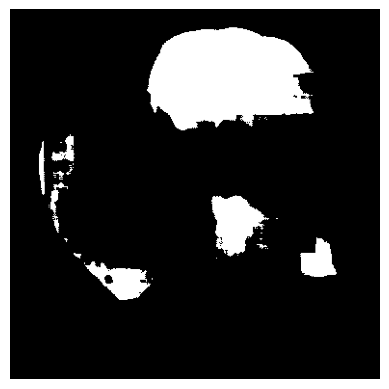

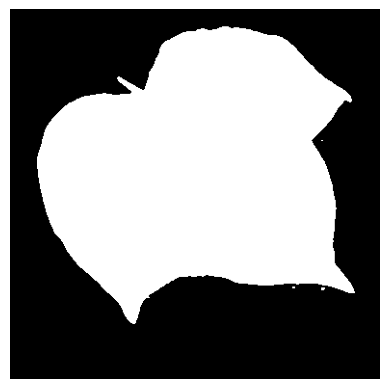

In [11]:
image = Image.open(r'data\PlantExpertVQA\images\0ad07c99921df75a.jpg')
image = np.asarray(image)
image = cv2.resize(image, (384,384))

image = image.astype(np.float32) / 255.0
image = np.transpose(image, (2,0,1))
image = np.expand_dims(image, axis=0)

#convert to np.ndarray
mask = best.predict(image)


img = Image.open(r'data\PlantExpertVQA\images\0ad07c99921df75a.jpg')
img = np.asarray(img)
img = cv2.resize(img, (384,384))

mask = (mask > 0.7).astype(np.uint8) * 255
mask = mask.squeeze()
plt.imshow(mask, cmap='gray') ; plt.axis('off') ; plt.show()
vals, counts = np.unique_counts(mask)
gray_Image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_Image, (5,5),0)
_, threshold = cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
#find contours
contours, hierarchy = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_mask = np.zeros_like(gray_Image)
cv2.drawContours(image=filled_mask, contours=contours, contourIdx=-1, color=(255,255,255), thickness=cv2.FILLED)
plt.imshow(filled_mask, cmap='gray') ; plt.axis('off') ; plt.show()